## Required packages before use in this order

> *pip install git+https://github.com/amr8004/ESPEI.git* <br>
<br>
> *pip install git+https://github.com/amr8004/pycalphad.git*

In [1]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
os.chdir('C:/Users/xander/Documents/github_repositories/PureElement')
os.getcwd()

'C:\\Users\\xander\\Documents\\github_repositories\\PureElement'

In [3]:

element = 'Hg'
#csvName = r'C:/Users/xander/Documents/github_repositories/PureElement/CpCSV/{element}_CP_data.csv'
csvName = f'CpCSV/{element}_CP_data.csv'
jsonName = f'CpJson/{element}_CP.json'

# Read the CSV and add the data to a dictionary
df=pd.read_csv(csvName, header=[0,0])
header = df.columns.tolist()
data = {}
for col in header:
    column_values = df[col].values.flatten().tolist()
    data[col[0]] = column_values[::]

In [4]:
print(data.keys())
data['Temperature: K']

dict_keys(['Temperature: K', 'Heat capacity at constant pressure Cp: J/K/mol', 'Uncertainty', 'Pressure', 'Ref Temp', 'Data Set ID', 'State', 'Representation', 'Method', 'Description', 'Purity', 'Purity Units', 'Year'])


[61.65,
 62.15,
 65.15,
 66.15,
 69.15,
 79.15,
 82.15,
 86.15,
 90.15,
 94.15,
 201.15,
 206.15,
 209.15,
 214.15,
 228.15,
 230.15,
 233.15,
 233.15,
 31.1,
 36.6,
 43.0,
 62.0,
 65.0,
 69.0,
 80.5,
 86.0,
 92.0,
 164.0,
 168.0,
 201.0,
 207.0,
 213.0,
 214.0,
 229.0,
 232.0,
 18.7,
 20.3,
 22.6,
 27.5,
 30.3,
 34.2,
 37.7,
 45.0,
 52.9,
 67.9,
 87.5,
 109.4,
 138.0,
 191.7,
 231.8,
 197.6,
 199.4,
 201.1,
 207.5,
 208.05,
 208.6,
 209.9,
 212.9,
 214.45,
 217.6,
 218.9,
 222.9,
 227.4,
 229.2,
 229.65,
 231.0,
 231.0,
 232.4,
 232.7,
 233.8,
 0.3522,
 0.3669,
 0.3968,
 0.4243,
 1.178,
 1.286,
 1.451,
 1.665,
 1.822,
 2.0,
 2.241,
 2.485,
 2.842,
 3.23,
 3.499,
 3.746,
 3.956,
 4.121,
 4.273,
 1.172,
 1.284,
 1.399,
 1.554,
 1.738,
 1.896,
 2.092,
 2.301,
 2.535,
 2.837,
 3.139,
 3.534,
 3.948,
 4.341,
 0.4529,
 0.4809,
 0.5173,
 0.5766,
 0.6328,
 0.7189,
 0.779,
 0.848,
 0.9228,
 0.9947,
 0.4745,
 0.5069,
 0.547,
 0.6044,
 0.6684,
 0.7505,
 0.7984,
 0.8538,
 0.9005,
 0.958,
 1.021,


In [5]:
if 'Temperature: K' in data:
    data['Temp'] = data.pop('Temperature: K')
else:
    print("Key ['Temperature: K'] does not exist in the data dictionary.")


In [6]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(jsonName), exist_ok=True)

# Open the file
with open(jsonName, 'w') as file:
    json.dump(data, file)

In [7]:

Define_Element([element.upper()])
data=imp_data_PE(jsonName)

In [8]:
# Load data from CSV
#data = pd.read_csv('sr_ipynb/Cr_Cp.txt', sep="\t")

# Extract columns
temp = data['Temp'].values
cp = data['Heat capacity at constant pressure Cp: J/K/mol'].values



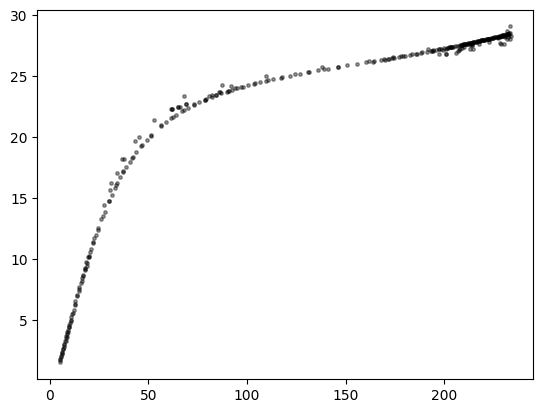

In [9]:
plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')

In [10]:
# Initial guess for parameters
initial_params = [230, 1e-3, 1e-6]  # You can adjust these initial guesses
initial_5params = [300, 1e-3, 0.01, 800, 300]
#initial_5params = [225, 1e-4, 1e-3, 150, 350]
nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [11]:
from espei.pureElement import log_probability

In [12]:
# Number of walkers and number of steps
nwalkers = 12
nsteps = 4000

model_flag='SRModelE'

# Set up the sampler
ndim = len(initial_5params)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_5params))
    for n,v in enumerate(initial_5params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
pos2 = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
# Run the MCMC sampling
sampler.run_mcmc(pos, nsteps, progress=True)


  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:41<00:00, 96.85it/s] 


State([[ 6.56827155e+01  1.81963013e-03  1.37627972e-02  3.29205854e+01
  -1.02470369e+02]
 [ 8.12205147e+01  5.77152373e-04  8.01706299e-03 -1.27201072e+02
   4.45560378e+02]
 [ 8.34339689e+01  2.64591053e-03  7.46257588e-02  6.07019160e+04
   6.32410019e+04]
 [ 8.81922478e+01  6.40859516e-04  5.11744453e-04 -4.82497614e+03
  -4.04609953e+03]
 [ 8.34990091e+01  2.51190809e-04  3.74661592e-02  6.02132111e+03
   7.26186382e+03]
 [ 8.28659882e+01  4.74824698e-03  9.57820939e-03  7.12720253e+04
   7.87812745e+04]
 [ 8.60725973e+01  3.09815222e-03  2.45800086e-02  2.75249608e+05
   2.85355347e+05]
 [ 8.62145147e+01  1.85404589e-03  5.56821997e-02  1.34595446e+05
   1.39288188e+05]
 [ 8.86151549e+01  1.17908971e-03  7.45955044e-03  2.66938056e+05
   2.86422396e+05]
 [ 8.74074621e+01  1.76843664e-03  4.81063415e-03  5.05999211e+05
   5.38867444e+05]
 [ 8.73198805e+01  1.52942348e-04  4.55509059e-02  1.38834315e+04
   1.56783706e+04]
 [ 8.26457518e+01  2.73545932e-03  3.37697884e-02  8.771172

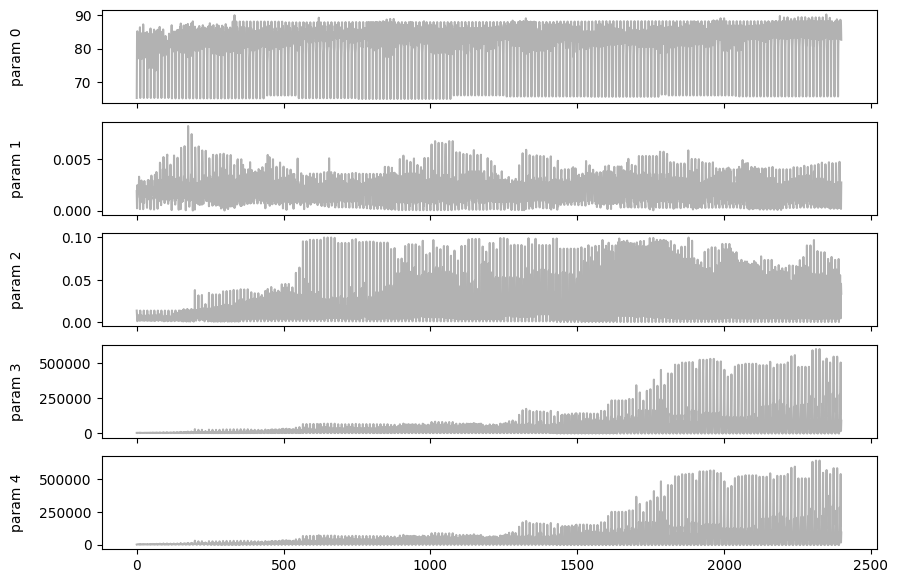

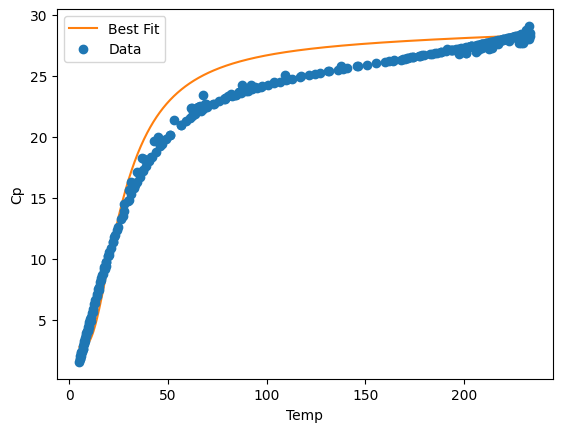

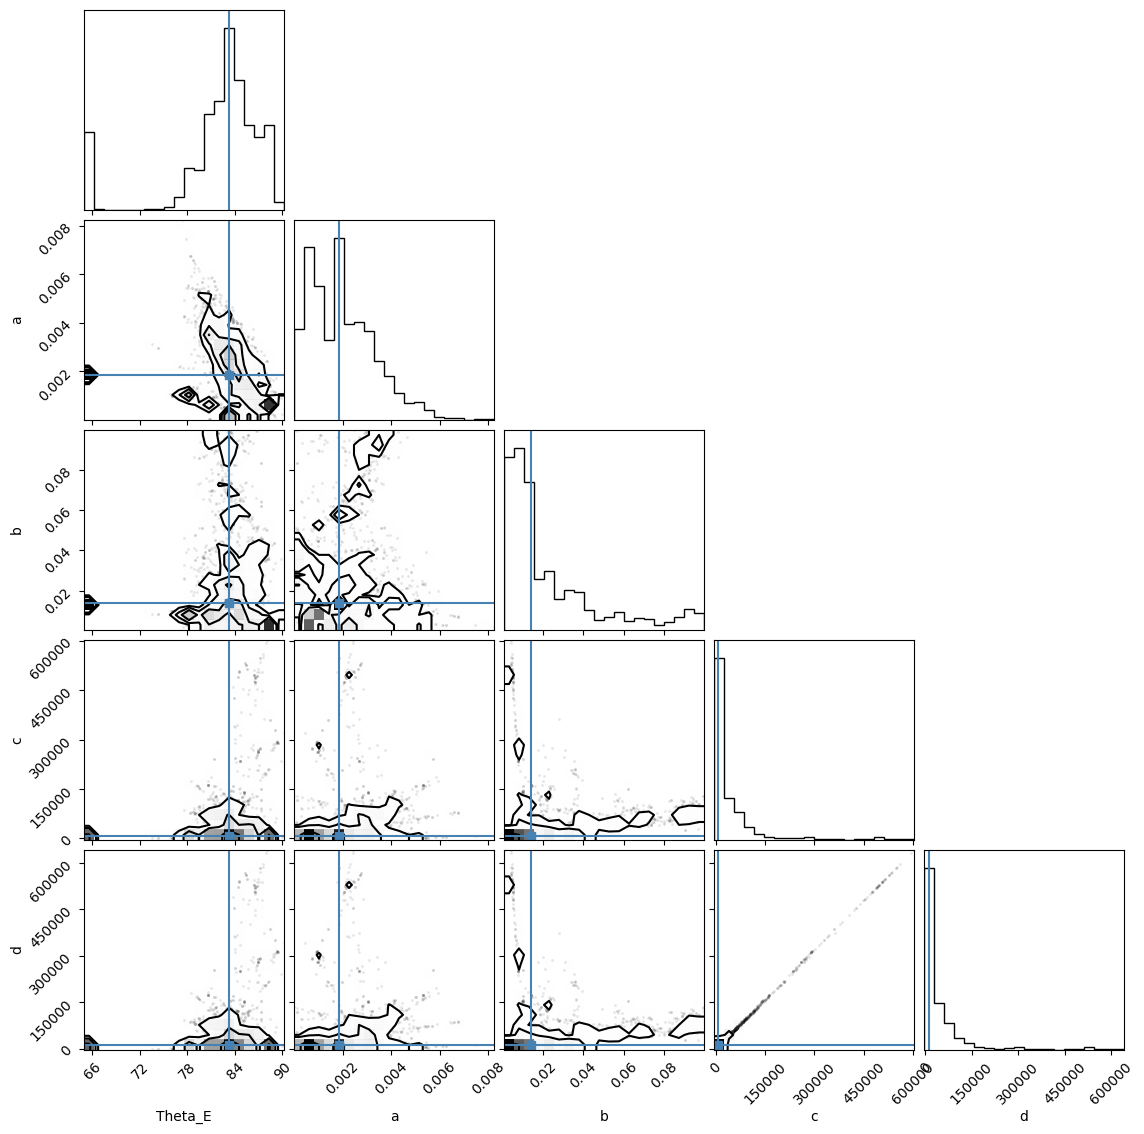

In [13]:
# Extract samples
samples = sampler.get_chain(flat=True, discard=1000, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params = np.median(samples, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples, labels=["Theta_E", "a", "b","c","d"], truths=best_params)
plt.show()


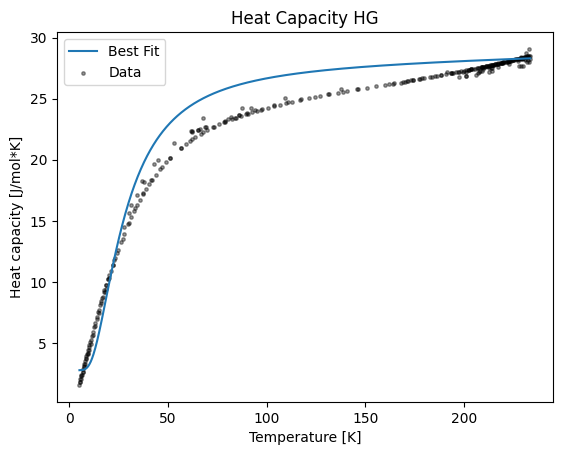

In [14]:
# Plot the best-fit curve with uncertainties
best_params = np.median(samples, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')


plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [15]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([8.33055095e+01, 1.83750358e-03, 1.37627972e-02, 7.94680997e+03,
       1.08959331e+04])

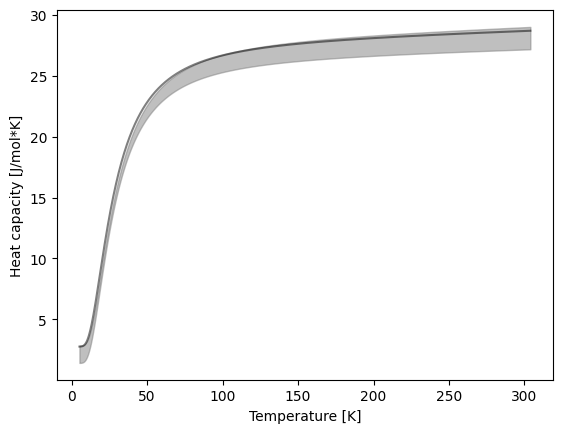

In [16]:
best_params = np.median(samples, axis=0)
mean_params = np.mean(samples, axis=0)
rangeSR=np.percentile(samples, [40, 50, 84], axis=0)
T_plot = np.linspace(min(temp), max(temp)*1.3, 1000)

plt.figure()
#plt.errorbar(temp, cp, fmt='o', label='Data', color = 'grey', alpha = 0.1)
#plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Median', color = 'b')
#plt.plot(T_plot, SRModelE(T_plot, *mean_params), label='Mean', color = 'red')
plt.plot(T_plot, SRModelE(T_plot, *rangeSR[1]), label='50th', color = 'k', alpha = 0.5)
sixteenth=SRModelE(T_plot, *rangeSR[0])
eightyfourth=SRModelE(T_plot, *rangeSR[2])
plt.fill_between(T_plot, sixteenth, eightyfourth, color='grey', alpha=0.5)
plt.plot
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
#plt.legend()
plt.show()

In [17]:
s1 = np.std(samples[:,0], ddof=1)
s2 = np.std(samples[:,1], ddof=1)
s3 = np.std(samples[:,2], ddof=1)
s4 = np.std(samples[:,3], ddof=1)
s5 = np.std(samples[:,4], ddof=1)

In [18]:
print('Standard deviation of Theta_E:', s1)
print('Standard deviation of a:', s2)
print('Standard deviation of b:', s3)
print('Standard deviation of c:', s4)
print('Standard deviation of d:', s5)

Standard deviation of Theta_E: 5.691528600511784
Standard deviation of a: 0.0013284265817875142
Standard deviation of b: 0.02477147216234675
Standard deviation of c: 89078.82162139718
Standard deviation of d: 94336.49245386792


In [19]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 1000

model_flag='CSModelE'

# Set up the sampler
ndim = len(initial_params)
sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler2.run_mcmc(pos, nsteps)


State([[6.55587989e+01 6.74341101e-04 1.27650226e-09]
 [6.56129326e+01 1.12101501e-05 1.35609453e-09]
 [6.85787032e+01 1.65351566e-03 1.20700508e-09]
 [6.68128110e+01 1.17322825e-03 1.21369895e-09]
 [6.69101934e+01 1.69259054e-03 1.20687505e-09]
 [6.66948457e+01 6.86925519e-04 1.32549179e-09]
 [6.77183888e+01 2.92497933e-03 1.05330516e-09]
 [6.82156048e+01 1.19200254e-03 1.23582360e-09]
 [6.65131066e+01 2.76409436e-03 1.13432031e-09]
 [6.49153982e+01 1.06064580e-03 1.26538117e-09]
 [6.63676610e+01 1.61791292e-03 1.14677263e-09]
 [6.64190323e+01 3.29388108e-04 1.23952927e-09]
 [6.65910334e+01 5.77455499e-04 1.29569841e-09]
 [6.70787423e+01 2.58191229e-03 1.15426268e-09]
 [6.61311414e+01 1.73889902e-03 1.17862211e-09]
 [6.59273023e+01 1.13025107e-03 1.29626086e-09]
 [6.76189265e+01 2.91938023e-03 1.10438831e-09]
 [6.63494785e+01 2.04758930e-03 1.16442884e-09]
 [6.61900579e+01 2.14712625e-03 1.14475206e-09]
 [6.68796963e+01 5.63087616e-06 1.30859637e-09]
 [6.52860496e+01 3.21926169e-04 1.

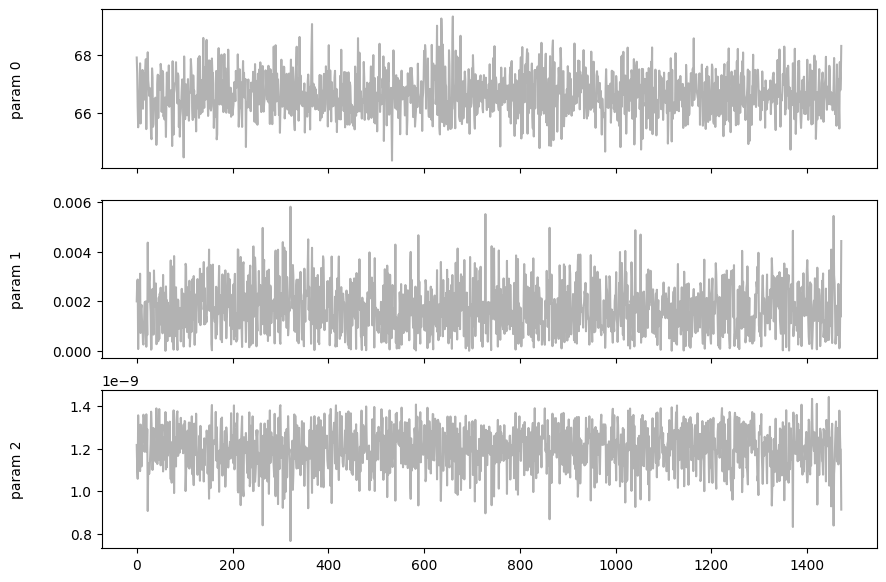

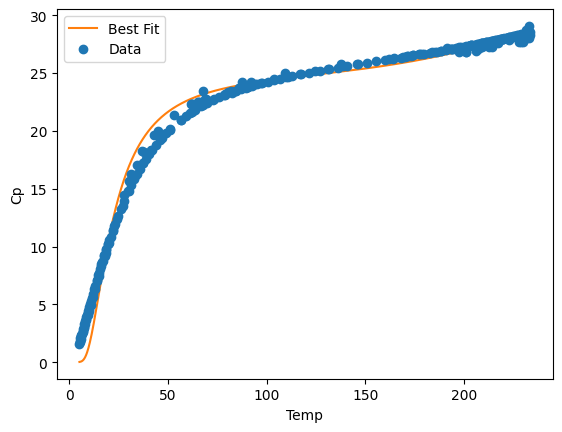

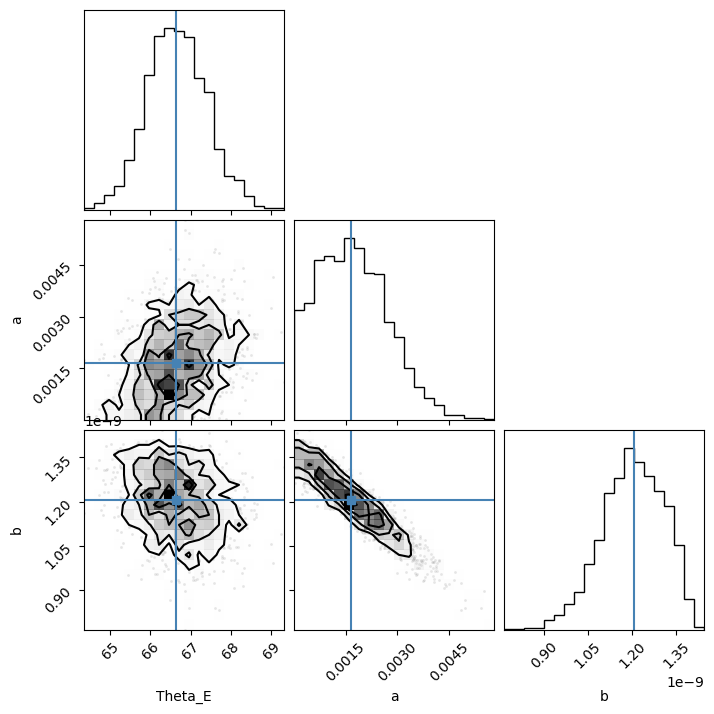

In [20]:
# Extract samples
samples2 = sampler2.get_chain(discard=300, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples2[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params2 = np.median(samples2, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples2, labels=["Theta_E", "a", "b"], truths=best_params2)
plt.show()


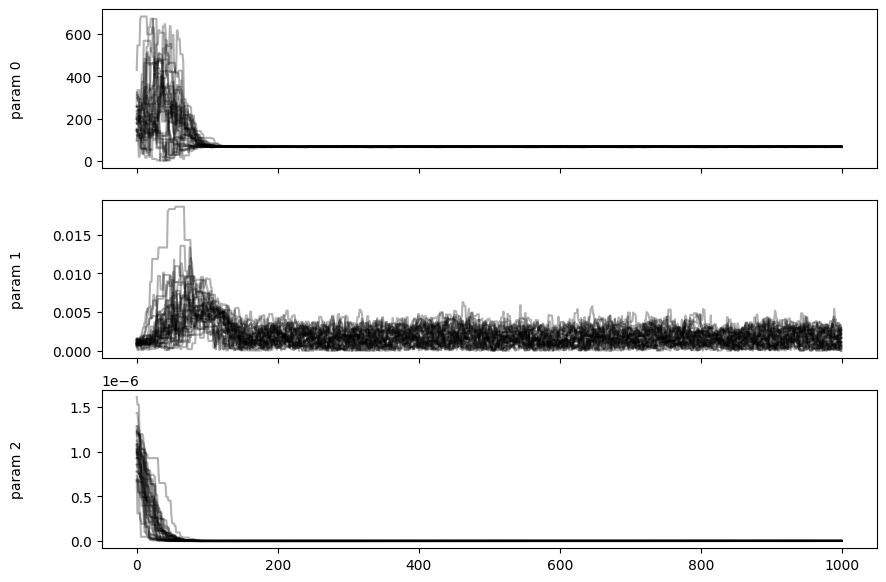

In [21]:
unflat2=sampler2.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [22]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.14f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([6.66465660e+01, 1.65201791e-03, 1.20489074e-09])

In [23]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 2000

model_flag='RWModelE'

# Set up the sampler
ndim = len(initial_params)
sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler3.run_mcmc(pos, nsteps)


State([[6.77409149e+01 3.44779204e-04 6.17762492e-05]
 [6.74634130e+01 2.56274711e-04 6.07904404e-05]
 [6.75037760e+01 1.99812424e-04 6.44369655e-05]
 [6.67684305e+01 1.04884861e-06 6.36980538e-05]
 [6.56684208e+01 4.15993604e-04 6.43415130e-05]
 [6.67974242e+01 6.43202137e-04 6.07780973e-05]
 [6.71539822e+01 5.19892953e-04 6.28436871e-05]
 [6.72063092e+01 8.44909085e-04 6.25200637e-05]
 [6.64623707e+01 3.49591911e-04 6.06026863e-05]
 [6.81374705e+01 6.68334243e-04 6.00143272e-05]
 [6.64744639e+01 1.53416572e-04 6.28357344e-05]
 [6.71195006e+01 1.44702820e-03 5.83850569e-05]
 [6.64194425e+01 8.47525226e-04 6.25330662e-05]
 [6.63316896e+01 6.52100648e-05 6.18286709e-05]
 [6.73728071e+01 4.87414092e-04 6.07023430e-05]
 [6.70334280e+01 2.71725068e-04 6.22047931e-05]
 [6.75966641e+01 9.49902107e-05 6.22106551e-05]
 [6.67991449e+01 2.12715147e-04 6.41593932e-05]
 [6.65239385e+01 4.26254873e-04 6.18524603e-05]
 [6.74937967e+01 6.44541089e-04 6.50500053e-05]
 [6.83628164e+01 1.18970085e-04 6.

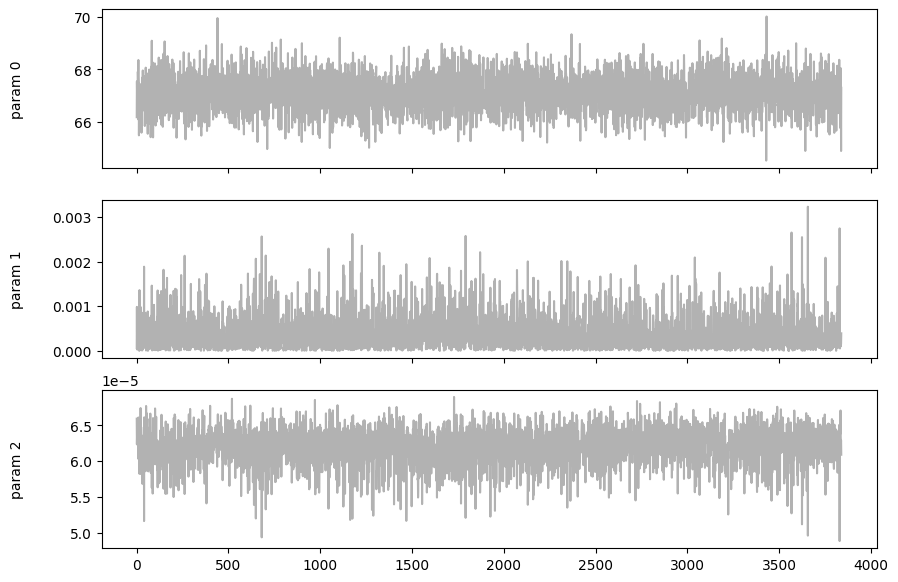

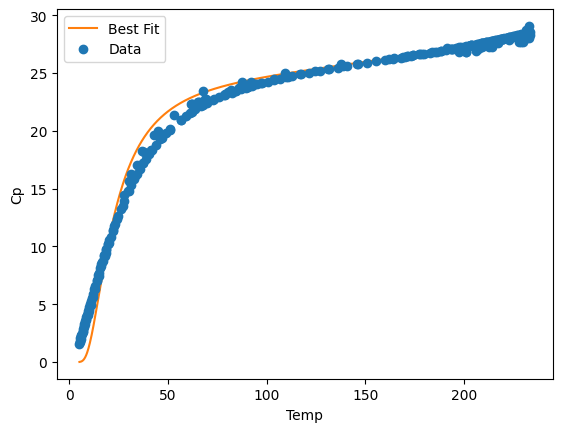

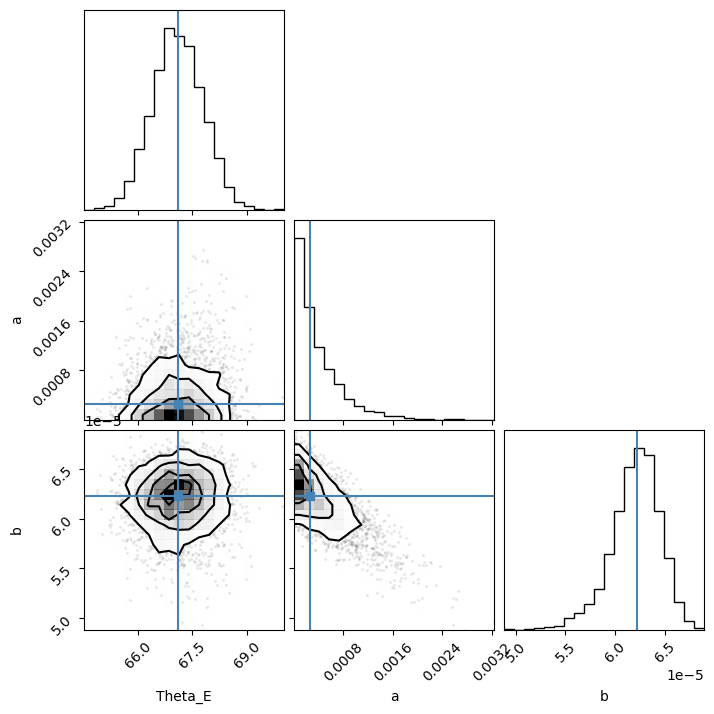

In [24]:
# Extract samples
samples3 = sampler3.get_chain(discard=200, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples3[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples3, labels=["Theta_E", "a", "b"], truths=best_params3)
plt.show()


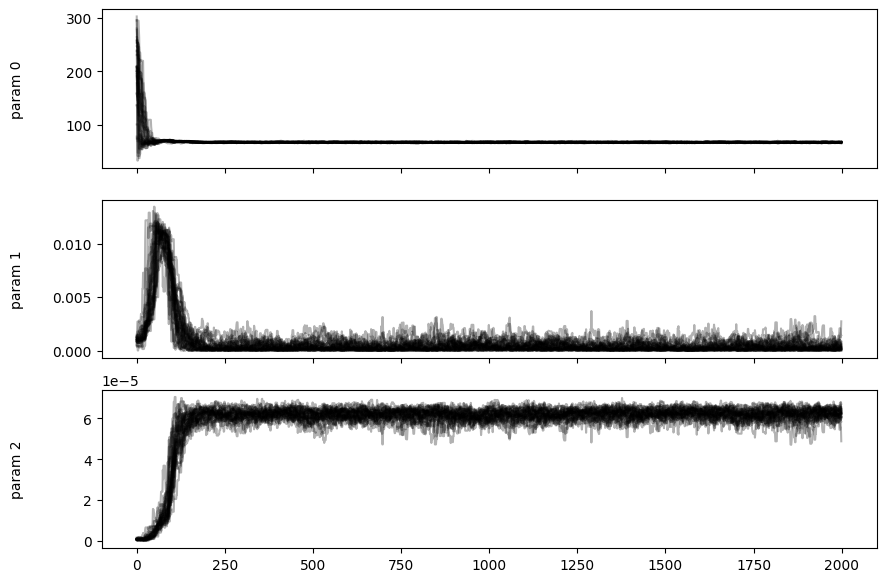

In [25]:
unflat2=sampler3.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [26]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples3[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params3)
for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params2)
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[6.70937949e+01 2.60772927e-04 6.22669191e-05]


<IPython.core.display.Math object>

...

[6.66465660e+01 1.65201791e-03 1.20489074e-09]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[8.33055095e+01 1.83750358e-03 1.37627972e-02 7.94680997e+03
 1.08959331e+04]


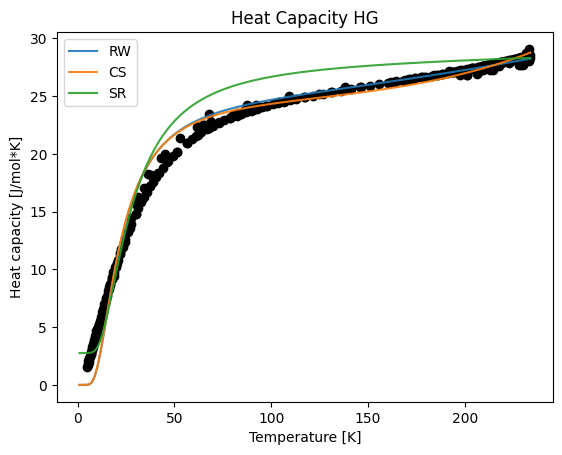

In [27]:
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(1, max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k')#,s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.gca().set_aspect(30)
#plt.xlim(0,200)
#plt.ylim(0,50)
plt.show()

In [28]:
RW=(RWModelE(T_plot, *best_params3))*(6.022e23)*(1.380649e-23)
CS=(CSModelE(T_plot, *best_params2))*(6.022e23)*(1.380649e-23)
SR=(np.array(SRModelE(T_plot, *best_params)))*(6.022e23)*(1.380649e-23)
cp2=(cp)*(6.022e23)*(1.380649e-23)

In [29]:
print(RW[0],CS[0],SR[0])

0.002685839948782425 0.013735330152056607 22.865299500329375


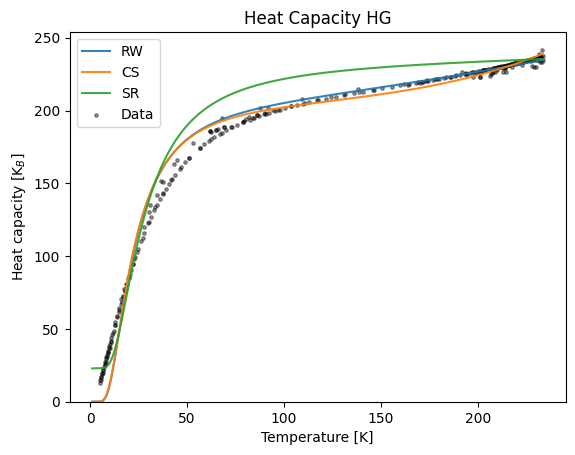

In [30]:
plt.figure()
plt.plot(T_plot, RW, label='RW', alpha=0.9)
plt.plot(T_plot, CS, label='CS', alpha=0.9)
plt.plot(T_plot, SR, label='SR', alpha=0.9)

plt.scatter(temp, cp2, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [K$_{B}$]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.xlim(300,900)
plt.ylim(0)
plt.show()

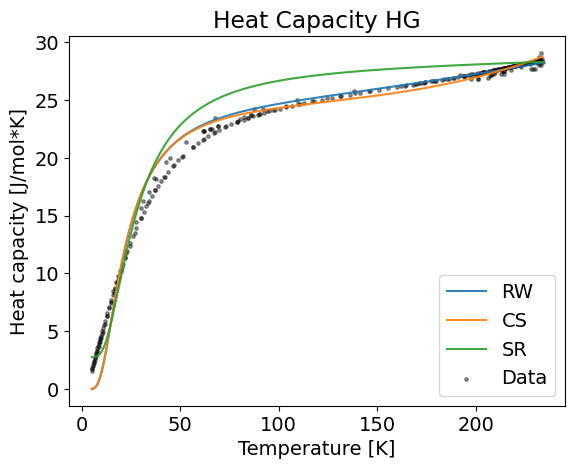

In [31]:
plt.rcParams.update({'font.size': 14})
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


-561.6889785329308 <class 'numpy.ndarray'> 200
0.00029190638702949936 <class 'numpy.ndarray'> 200
sr


c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1954: RuntimeWarning: invalid value encountered in log
  S = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))*x+(k1-k2*(alfa-g)/(2.0*g))*x**2+k2/(8.0*g)*x**3.0+k2/(4.0*g)*(alfa-g)**2.0*x*np.log(x)


Text(0.5, 1.0, 'Gibbs HG')

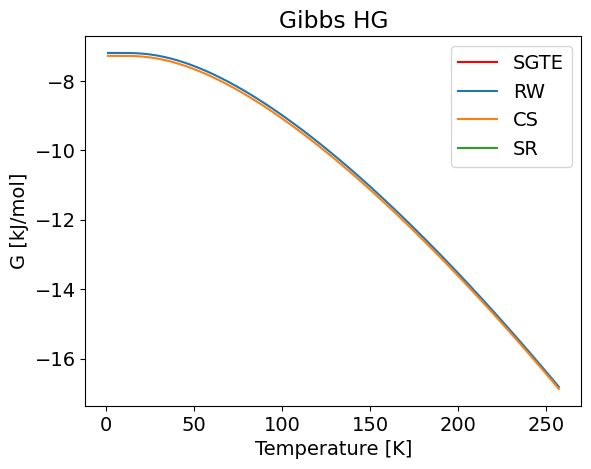

In [32]:
CSa=best_params2[1]
CSb=best_params2[2]
CSE=best_params2[0]

RWE = best_params3[0]
RWa=best_params3[1]
RWb=best_params3[2]

RTDB_globals['Te_final'] = best_params[0]
RTDB_globals['k1_final'] = best_params[1]
RTDB_globals['k2_final'] = best_params[2]
RTDB_globals['alfa_final'] = best_params[3]
RTDB_globals['g_final'] = best_params[4]
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')
T_range = np.linspace(1,data.Temp.max()*1.1,num=200)
fcc_GM = calculate(db_sgte, [element.upper(), 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE', color = 'r')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
GSRtest=pype.GEin(RTDB_globals['Te_final'],T_range)+pype.GTBCM(T_range,RTDB_globals['k1_final'],RTDB_globals['k2_final'],RTDB_globals['alfa_final'],RTDB_globals['g_final'])#+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GSRtest/1000, label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("G [kJ/mol]")
plt.legend()
plt.title(f"Gibbs {RTDB_globals['element'][0]}")

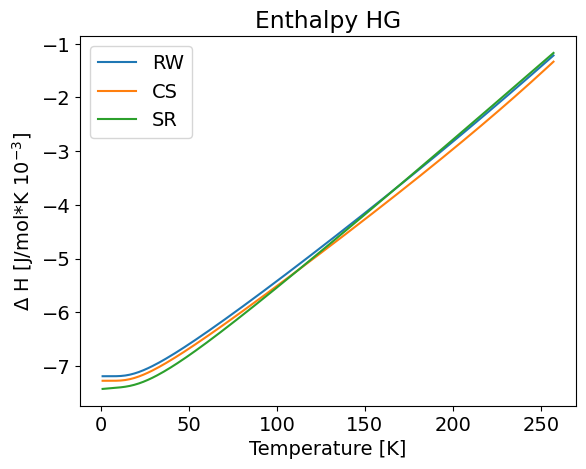

In [33]:
HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSE,298.15)#+pype.HM(T_range)[29]
HSR298=pype.HTBCM(298.15,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],298.15)#+pype.HM(T_range)[149]
HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)#+pype.HM(T_range)[149]
HCS=pype.HTCSM(T_range,CSa,CSb)+pype.HEin(CSE,T_range)#+pype.HM(T_range)
HCS2=HCS-HCS298
HSR2=pype.HTBCM(T_range,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],T_range)#+pype.HM(T_range)
HSR=HSR2-HSR298
HRW2=pype.HTRWM(T_range,RWa,RWb)+pype.HEin(RWE,T_range)#+pype.HM(T_range)
HRW=HRW2-HRW298
plt.plot(T_range,10**-3*HRW,label='RW')
plt.plot(T_range,10**-3*HCS2,label='CS')
plt.plot(T_range,10**-3*HSR,label='SR')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
plt.title("H_Ein+H_BCM-H298.15")
plt.title(f"Enthalpy {RTDB_globals['element'][0]}")
plt.legend()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1935: RuntimeWarning: invalid value encountered in log
  Si = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))+(k1-k2*(alfa-g)/(2.0*g))*i+k2/(8.0*g)*i**2+k2/(4.0*g)*(alfa-g)**2.0*np.log(i)


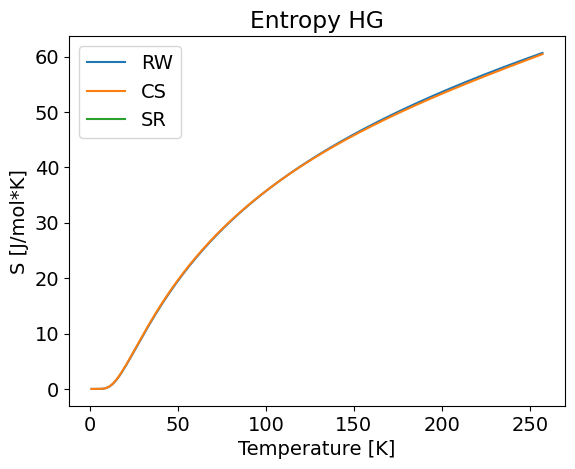

In [34]:
SE1=pype.SEin(RTDB_globals['Te_final'],T_range)
SBCM1=pype.STBCM(T_range, RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])
#Smag=pype.SM(T_range)
Scomb=SBCM1+SE1#+Smag
SRW=pype.STRWM(T_range,RWa,RWb)+pype.SEin(RWE,T_range)#+Smag
SCS=pype.STCSM(T_range,CSa,CSb)+pype.SEin(CSE,T_range)#+Smag
plt.plot(T_range,SRW,label = 'RW')
plt.plot(T_range,SCS,label = 'CS')
plt.plot(T_range,Scomb,label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
plt.title(f"Entropy {RTDB_globals['element'][0]}")
plt.legend()

In [35]:
def PE_AICC(nparm, nobs,logLik,aicc_factor=None, kk=2):
    #print('CHECKPOINT AICC CALLED')
    k= nparm
    n = nobs
    AIC = -2 * logLik + kk *(k+1)
    print('k=',k,
    'n=',n)
    p=aicc_factor if aicc_factor is not None else 1.0
    pk = nparm*p
    aic = -2*logLik+2*(nparm+1)
    print('aic2:', aic)
    if pk >= (n-1.0):
        # Prevent the denominator of the proper mAICc from blowing up (pk = n - 1) or negative (pk > n - 1)
        correction = (2.0* p**2 * k**2 + 2.0 * pk) * (-n + pk + 3.0)
    else:
        correction = (2.0 * p**2 * k**2 + 2.0 * pk) / (n - pk - 1.0)
    aicc = aic+correction
    print('correction: ',correction)
    #print('CHECKPOINT AICC SOLVED')
    return aicc

nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [36]:
RW_logLik = log_likelihood(best_params3,temp,cp,'RWModelE')
AICC_RW=PE_AICC(nparm,nobs,RW_logLik)

CS_logLik = log_likelihood(best_params2,temp,cp,'CSModelE')
AICC_CS=PE_AICC(nparm,nobs,CS_logLik)

SR_logLik = log_likelihood(best_params,temp,cp,'SRModelE')
AICC_SR=PE_AICC(nparm5,nobs,SR_logLik)

k= 3 n= 308
aic2: 449.6045592356314
correction:  0.07894736842105263
k= 3 n= 308
aic2: 443.3948194527403
correction:  0.07894736842105263
k= 5 n= 308
aic2: 689.0545700921855
correction:  0.1986754966887417


In [37]:
print('AICC_RW:', AICC_RW)
print('AICC_CS:', AICC_CS)
print('AICC_SR:', AICC_SR)

AICC_RW: 449.68350660405247
AICC_CS: 443.47376682116135
AICC_SR: 689.2532455888743
